# Week 4 — Math Intuition for ML + Mini Project
**AI/ML Internship Program — Month 1: Foundations**

This notebook covers:
1. Intuitive math for ML — vectors, matrices, dot products, probability, gradients
2. A hands-on gradient descent demo
3. **Mini Project:** Full EDA on a new, independent dataset — the Palmer Penguins dataset

## 1. Vectors, Matrices, and Dot Products

- A **vector** is just a list of numbers — e.g. a data point with 3 features is a vector in 3D space.
- A **matrix** is a table of numbers — a full dataset (rows = samples, columns = features) is a matrix.
- The **dot product** measures how much two vectors "point in the same direction." In ML, it's the core operation behind predictions: `prediction = weights · features`.
- **Matrix multiplication** is just doing many dot products at once — this is how a whole dataset gets multiplied by a whole set of weights in one shot.

In [1]:
import numpy as np

# A single data point (feature vector): [study_hours, sleep_hours, attendance_pct]
x = np.array([5, 7, 90])

# Weights the model has "learned" for each feature
w = np.array([0.6, 0.3, 0.05])

# Dot product = weighted sum = the model's raw prediction
prediction = np.dot(x, w)
print("Feature vector:", x)
print("Weights:", w)
print("Dot product (prediction):", prediction)

Feature vector: [ 5  7 90]
Weights: [0.6  0.3  0.05]
Dot product (prediction): 9.6


In [2]:
# Matrix multiplication = many dot products at once
# 4 students (rows), 3 features each (columns)
X = np.array([
    [5, 7, 90],
    [2, 5, 60],
    [8, 6, 95],
    [4, 4, 70]
])

predictions = X @ w   # '@' is matrix multiplication in numpy
print("Dataset (4 students x 3 features):\n", X)
print("\nPredictions for all 4 students at once:", predictions)

Dataset (4 students x 3 features):
 [[ 5  7 90]
 [ 2  5 60]
 [ 8  6 95]
 [ 4  4 70]]

Predictions for all 4 students at once: [ 9.6   5.7  11.35  7.1 ]


## 2. Probability Basics

- **Probability** = how likely something is, between 0 and 1.
- **Conditional probability** `P(A | B)` = probability of A, *given that we already know B happened*.
- A **distribution** describes how likely each possible value is. The Normal (bell curve) distribution shows up constantly in ML.

In [3]:
import numpy as np
rng = np.random.default_rng(42)

# Simulate 1000 students' exam scores, normally distributed
scores = rng.normal(loc=70, scale=10, size=1000)

print(f"Mean score: {scores.mean():.2f}")
print(f"Std dev: {scores.std():.2f}")

# P(score > 85) -- an example of using a distribution to estimate probability
p_above_85 = (scores > 85).mean()
print(f"P(score > 85) ≈ {p_above_85:.3f}")

Mean score: 69.71
Std dev: 9.89
P(score > 85) ≈ 0.062


## 3. Derivatives, Gradients & Gradient Descent

- A **derivative** tells you the slope of a function at a point.
- A **gradient** generalizes this to multiple variables — it points toward steepest increase.
- **Gradient descent** = take small steps *opposite* the gradient to find the minimum. This is how models "learn."

Below: gradient descent finds the minimum of `f(x) = (x - 3)^2`, whose true minimum is `x = 3`.

Final x after gradient descent: 2.9889  (true minimum is 3)


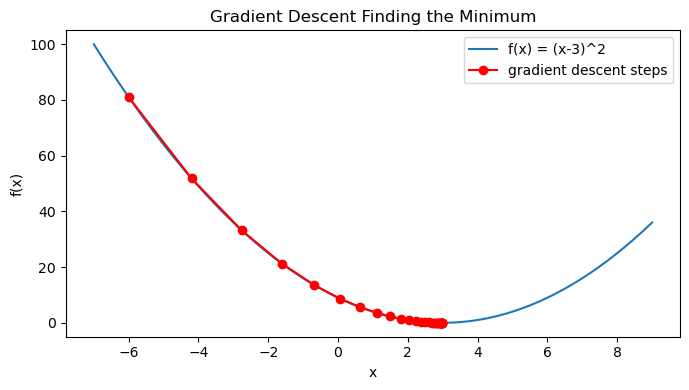

In [4]:
import matplotlib.pyplot as plt

def f(x):
    return (x - 3) ** 2

def gradient(x):
    return 2 * (x - 3)

x = -6.0
learning_rate = 0.1
history = [x]

for step in range(30):
    x = x - learning_rate * gradient(x)
    history.append(x)

print(f"Final x after gradient descent: {history[-1]:.4f}  (true minimum is 3)")

xs = np.linspace(-7, 9, 200)
plt.figure(figsize=(7, 4))
plt.plot(xs, f(xs), label="f(x) = (x-3)^2")
plt.plot(history, [f(v) for v in history], 'o-', color='red', label="gradient descent steps")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent Finding the Minimum")
plt.legend()
plt.tight_layout()
plt.show()